In [8]:
from pathlib import Path

BASE_DIR = Path.cwd()
if BASE_DIR.name == 'notebooks':
    BASE_DIR = BASE_DIR.parent   # go up to project root

INPUT_FILE  = BASE_DIR / "data" / "processed" / "cleaned_retail_dataset.csv"
REPORTS_DIR = BASE_DIR / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

In [9]:
import pandas as pd
# Load Data to Pandas Dataframe
retail_df = pd.read_csv(INPUT_FILE,
                       dtype = {'InvoiceNo': 'category' , 'StockCode':'category' , 'Description':'category' , 'Country':'category' })
# Print First Five rows of the Dataset

retail_df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,MonthNumber,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850.0,United Kingdom,15.30,2010,12,December
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850.0,United Kingdom,20.34,2010,12,December
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850.0,United Kingdom,22.00,2010,12,December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850.0,United Kingdom,20.34,2010,12,December
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850.0,United Kingdom,20.34,2010,12,December


In [10]:
# Findout Current Maximum Date from the Dataset

current_date = pd.to_datetime(retail_df['InvoiceDate'] , errors = 'coerce').max() + pd.Timedelta(days = 1)

current_date

Timestamp('2011-12-10 00:00:00')

## Calculate RFM For each Customers

In [11]:
retail_df['InvoiceDate'] = pd.to_datetime(retail_df['InvoiceDate'] , errors = 'coerce')

df1 = retail_df.groupby(by = 'CustomerID').agg({
    'InvoiceDate': lambda x: (current_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice' : 'sum'
})

df1.rename(columns = {'InvoiceDate':'Recency', 'InvoiceNo':'Frequency' , 'TotalPrice':'Monetary'} , inplace = True)

rfm = df1.reset_index()

rfm

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,3,7,3764.48
2,12348.0,76,4,1114.00
3,12349.0,19,1,1668.75
4,12350.0,311,1,295.30
...,...,...,...,...
4299,18280.0,278,1,180.60
4300,18281.0,181,1,65.70
4301,18282.0,8,2,152.45
4302,18283.0,4,16,1714.85


In [12]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4304.000000,4304.000000,4304.000000,4304.000000
mean,15299.845028,93.262314,4.225139,1822.075044
std,1720.396575,100.313542,7.531495,8353.798280
min,12346.000000,1.000000,1.000000,3.750000
25%,13814.750000,18.000000,1.000000,255.812500
50%,15298.500000,51.000000,2.000000,576.800000
75%,16777.250000,143.250000,5.000000,1429.627500
max,18287.000000,374.000000,201.000000,257518.900000


## Segment Customer Based on RFM

In [13]:
# Recency (recent = better)
rfm['R_Segment'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])

# Frequency (higher = better) 
try:
    rfm['F_Segment'] = pd.qcut(rfm['Frequency'], 4, labels=[1, 2, 3, 4])
except ValueError:
    rfm['F_Segment'] = pd.qcut(rfm['Frequency'], 4, labels=False, duplicates='drop') + 1

# Monetary (higher = better) 
try:
    rfm['M_Segment'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])
except ValueError:
    rfm['M_Segment'] = pd.qcut(rfm['Monetary'], 4, labels=False, duplicates='drop') + 1

# RFM Score
rfm['RFM_Score'] = rfm[['R_Segment', 'F_Segment', 'M_Segment']].sum(axis=1)

rfm.sort_values(by = 'RFM_Score' , ascending = False)

,CustomerID,Recency,Frequency,Monetary,R_Segment,F_Segment,M_Segment,RFM_Score
2655,15993.0,9,7,2187.63,4,3,4,11
427,12901.0,11,21,9857.16,4,3,4,11
2896,16326.0,6,14,3007.78,4,3,4,11
466,12955.0,2,10,3789.98,4,3,4,11
1362,14217.0,2,17,1819.14,4,3,4,11
...,...,...,...,...,...,...,...,...
3106,16617.0,236,1,141.45,1,1,1,3
3839,17643.0,374,1,55.35,1,1,1,3
1932,15019.0,267,1,222.64,1,1,1,3
3101,16611.0,187,1,124.45,1,1,1,3


In [14]:
# RFM Score Wise Customer Count
rfm_score_wise_customer_count  = rfm.groupby(by = 'RFM_Score')['CustomerID'].count().reset_index().rename(columns = {'CustomerID':'TotalCustomers'})

rfm_score_wise_customer_count

,RFM_Score,TotalCustomers
0,3,490
1,4,587
2,5,580
3,6,564
4,7,465
5,8,451
6,9,386
7,10,335
8,11,446


## Customer RFM Score Distribution

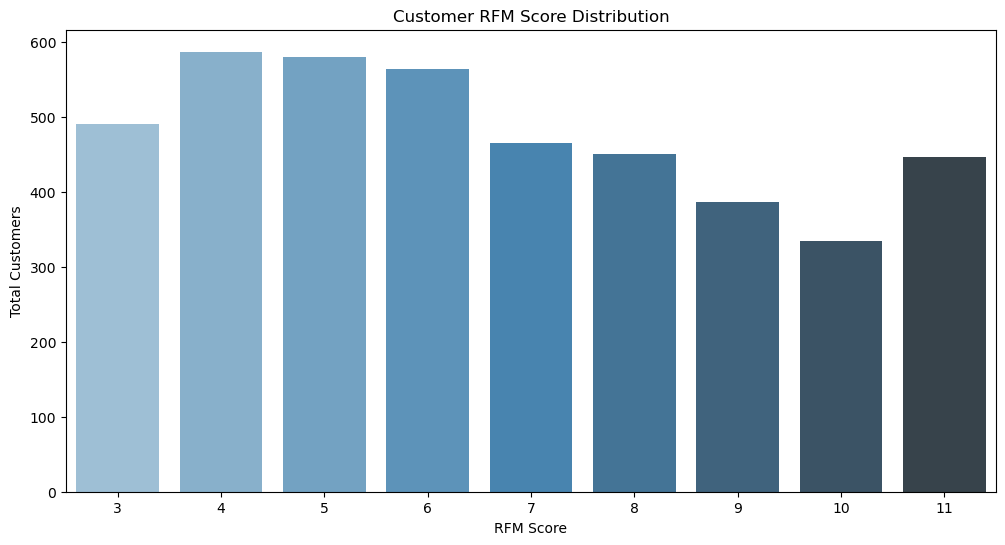

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(
    data=rfm_score_wise_customer_count,
    x='RFM_Score',
    y='TotalCustomers',
    palette='Blues_d'
)



plt.title('Customer RFM Score Distribution')
plt.xlabel('RFM Score')
plt.ylabel('Total Customers')
plt.show()

## Customer Churn Analysis

In [16]:
retail_df['InvoiceDate'] = pd.to_datetime(retail_df['InvoiceDate'] , errors = 'coerce')

customer_last_purchase = retail_df.groupby(by = 'CustomerID')['InvoiceDate'].max().reset_index().rename(columns = {'InvoiceDate':'Last_Purchase_date'})

customer_last_purchase['Days_Since_Last_Purchase'] = (current_date -  customer_last_purchase['Last_Purchase_date']).dt.days

customer_last_purchase

,CustomerID,Last_Purchase_date,Days_Since_Last_Purchase
0,12346.0,2011-01-18,326
1,12347.0,2011-12-07,3
2,12348.0,2011-09-25,76
3,12349.0,2011-11-21,19
4,12350.0,2011-02-02,311
...,...,...,...
4299,18280.0,2011-03-07,278
4300,18281.0,2011-06-12,181
4301,18282.0,2011-12-02,8
4302,18283.0,2011-12-06,4


## Define Customer Churn Thresold (e.g; 90 days without any purchase)

In [17]:
churn_threshold = 90

churn_customers = customer_last_purchase[customer_last_purchase['Days_Since_Last_Purchase'] > churn_threshold]

print('Total Churn Customers: ', len(churn_customers))

Total Churn Customers:  1440


## Visualize Customer churn Distribution

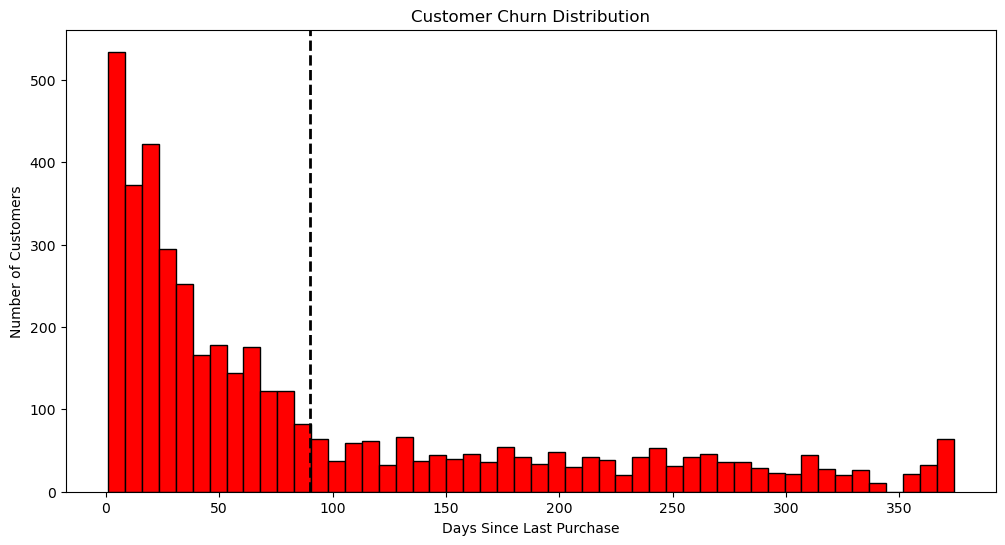

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Histogram of Days Since Last Purchase
sns.histplot(
    data=customer_last_purchase,
    x='Days_Since_Last_Purchase',
    bins=50,
    color='red',
    alpha= 1
)

# Churn threshold line
plt.axvline(churn_threshold, color='black', linestyle='dashed', linewidth=2)

# Labels and title
plt.title('Customer Churn Distribution')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Number of Customers')

plt.show()